# Best Model — RoBERTa-base with Data Augmentation (Two-Phase)

## Phase 1 — Train + eval → `dev.txt`
- Training data: official train split + `augmented_train_data.csv`
- Evaluated on official dev split; best checkpoint saved by macro-F1
- Produces `dev.txt` (2094 lines)

## Phase 2 — Full retrain → `test.txt`
- Training data: train + aug_train + **dev + aug_dev** (no held-out set)
- Fresh `roberta-base` trained for the same number of epochs
- Produces `test.txt` (3832 lines)

**Model**: `roberta-base` · **Optimiser**: AdamW (cosine + 10% warmup) · **Loss**: class-weighted CE

In [1]:
!pip install contractions python-dotenv huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00


In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print('HF token loaded.')
else:
    print('HF_TOKEN not found; proceeding without login.')

HF token loaded.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME  = 'roberta-base'
RUN_NAME = 'final_model'
MAX_LENGTH  = 256

# Notebook lives in BestModel/; data files are one level up
DATA_ROOT      = '/kaggle/input/datasets/wowthecoder/patronizing-and-condescending-language-detection'
AUG_ROOT       = '/kaggle/input/datasets/wowthecoder/pcl-data-augmentation'
OUTPUT_ROOT    = '/kaggle/working/'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH      = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')
AUG_TRAIN_PATH = os.path.join(AUG_ROOT, 'augmented_train_data.csv')
AUG_DEV_PATH   = os.path.join(AUG_ROOT, 'augmented_dev_data.csv')

# Phase 1 checkpoint dir (train split only)
RUN_NAME_P1 = 'checkpoints/phase1'
# Phase 2 checkpoint dir (full data)
RUN_NAME_P2 = 'checkpoints/phase2'

DEV_TXT_PATH  = 'dev.txt'
TEST_TXT_PATH = 'test.txt'

os.makedirs(RUN_NAME_P1, exist_ok=True)
os.makedirs(RUN_NAME_P2, exist_ok=True)
print('Checkpoint dirs created.')

Checkpoint dirs created.


In [5]:
# ============================================================
# Helper functions
# ============================================================
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)


def load_test_tsv(test_path: str) -> pd.DataFrame:
    """Load unlabelled test set (tab-separated, no header)."""
    rows = []
    with open(test_path, encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 5:
                continue
            rows.append({
                'par_id':  parts[0],
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
            })
    return pd.DataFrame(rows)


def load_aug_csv(path: str) -> pd.DataFrame:
    """Load an augmented data CSV, drop stray header rows, cast label to int."""
    aug = pd.read_csv(path, dtype={'par_id': str})
    aug = aug[aug['label'].astype(str) != 'label'].copy()
    aug['label'] = aug['label'].astype(int)
    if 'clean_text' in aug.columns:
        aug['clean_text'] = aug['clean_text'].fillna(aug['text'].apply(preprocess_text))
    else:
        aug['clean_text'] = aug['text'].apply(preprocess_text)
    aug['model_text'] = make_model_text(aug)
    return aug[['par_id', 'keyword', 'country', 'text', 'clean_text', 'model_text', 'label']]


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def make_model_text(frame: pd.DataFrame) -> pd.Series:
    kw  = frame['keyword'].fillna('').astype(str).str.strip()
    cc  = frame['country'].fillna('').astype(str).str.strip()
    txt = frame['clean_text'].fillna('').astype(str).str.strip()
    return kw + ' </s> ' + cc + ' </s> ' + txt

In [6]:
# ============================================================
# Load labelled dataset + preprocess
# ============================================================
df = load_task1(TSV_PATH)
df['clean_text'] = df['text'].apply(preprocess_text)
df['model_text'] = make_model_text(df)

print(f'Full labelled dataset: {len(df):,} rows')
print(df['label'].value_counts().rename({0: 'No-PCL', 1: 'PCL'}))

Full labelled dataset: 10,469 rows
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official train / dev split
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df   = pd.read_csv(DEV_IDS_PATH,   dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids   = set(dev_ids_df['par_id'].astype(str))

train_base_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)

# Dev set ordered exactly as the official split file (required for correct dev.txt)
dev_base_df = (
    dev_ids_df[['par_id']]
    .merge(df[df['par_id'].isin(dev_par_ids)], on='par_id', how='left')
    .reset_index(drop=True)
)

# Leftover samples not in either split go to train
leftover = df[~df['par_id'].isin(train_par_ids | dev_par_ids)]
if len(leftover):
    train_base_df = pd.concat([train_base_df, leftover], ignore_index=True)
    print(f'Appended {len(leftover):,} leftover samples to train.')

print(f'Train base: {len(train_base_df):,} | PCL={int((train_base_df.label==1).sum()):,} | No-PCL={int((train_base_df.label==0).sum()):,}')
print(f'Dev base:   {len(dev_base_df):,}  | PCL={int((dev_base_df.label==1).sum()):,}  | No-PCL={int((dev_base_df.label==0).sum()):,}')

Train base: 8,375 | PCL=794 | No-PCL=7,581
Dev base:   2,094  | PCL=199  | No-PCL=1,895


In [8]:
# ============================================================
# Load augmented data
# ============================================================
aug_train_df = load_aug_csv(AUG_TRAIN_PATH)
aug_dev_df   = load_aug_csv(AUG_DEV_PATH)

print(f'aug_train : {len(aug_train_df):,} rows | PCL={int((aug_train_df.label==1).sum()):,}')
print(f'aug_dev   : {len(aug_dev_df):,} rows  | PCL={int((aug_dev_df.label==1).sum()):,}')

aug_train : 6,352 rows | PCL=6,352
aug_dev   : 1,194 rows  | PCL=1,194


In [9]:
# ============================================================
# Tokenisation helpers
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


def build_dataset(frame: pd.DataFrame, has_labels: bool = True) -> Dataset:
    cols = ['model_text', 'label'] if has_labels else ['model_text']
    ds = (
        Dataset.from_pandas(
            frame[cols].rename(columns={'model_text': 'text'}),
            preserve_index=False,
        )
        .map(tokenize, batched=True, remove_columns=['text'])
    )
    if has_labels:
        ds = ds.rename_column('label', 'labels')
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    else:
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    return ds

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [10]:
# ============================================================
# Evaluation metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1_pcl": f1_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "precision_pcl": precision_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "recall_pcl": recall_score(labels, preds, average="binary", pos_label=1, zero_division=0),
    }

---
## Phase 1 — Train on train split + augmented train data
Trains with dev as validation set; best checkpoint (by macro-F1) is restored at end.

In [11]:
# ============================================================
# Phase 1 training set: train_base + aug_train
# ============================================================
p1_train_df = pd.concat([train_base_df, aug_train_df], ignore_index=True)
p1_train_df = p1_train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Phase 1 train: {len(p1_train_df):,} | PCL={int((p1_train_df.label==1).sum()):,} | No-PCL={int((p1_train_df.label==0).sum()):,}')

p1_train_ds = build_dataset(p1_train_df)
p1_dev_ds   = build_dataset(dev_base_df)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(p1_train_ds)
print(p1_dev_ds)

Phase 1 train: 14,727 | PCL=7,146 | No-PCL=7,581


Map:   0%|          | 0/14727 [00:00<?, ? examples/s]

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 14727
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [ ]:
# ============================================================
# Phase 1 model + trainer
# ============================================================
p1_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p1_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    metric_for_best_model="f1_pcl",
    greater_is_better=True,
    load_best_model_at_end=True,
    # warmup_steps=400,
    eval_delay=1000,
    report_to='none',
    seed=SEED,
)

p1_trainer = Trainer(
    model=p1_model,
    args=p1_args,
    train_dataset=p1_train_ds,
    eval_dataset=p1_dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)],
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
p1_train_result = p1_trainer.train()
print(p1_train_result)

Step,Training Loss,Validation Loss,F1 Pcl,Precision Pcl,Recall Pcl
1000,0.549717,0.692220,0.438356,0.301318,0.804020
1500,0.480340,0.514396,0.510998,0.385204,0.758794
2000,0.408987,0.458885,0.544484,0.421488,0.768844
2500,0.361264,0.468710,0.571956,0.451895,0.778894
3000,0.338344,0.455632,0.597938,0.506993,0.728643
3500,0.291163,0.446883,0.599562,0.531008,0.688442
4000,0.201446,0.562871,0.601660,0.512367,0.728643
4500,0.188666,0.422244,0.621687,0.597222,0.648241
5000,0.135784,0.513277,0.588859,0.623596,0.557789
5500,0.155100,0.653146,0.586667,0.472393,0.773869


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7000, training_loss=0.2863767307826451, metrics={'train_runtime': 582.0178, 'train_samples_per_second': 50.607, 'train_steps_per_second': 12.653, 'total_flos': 1407651340618920.0, 'train_loss': 0.2863767307826451, 'epoch': 1.9011406844106464})


# Error Analysis

Phase 1 dev metrics (best checkpoint):
  eval_loss: 0.4224
  eval_f1_pcl: 0.6199
  eval_precision_pcl: 0.5981
  eval_recall_pcl: 0.6432
  eval_runtime: 8.6335
  eval_samples_per_second: 242.5440
  eval_steps_per_second: 30.3470
  epoch: 1.9011

              precision    recall  f1-score   support

      No-PCL     0.9622    0.9546    0.9584      1895
         PCL     0.5981    0.6432    0.6199       199

    accuracy                         0.9250      2094
   macro avg     0.7802    0.7989    0.7891      2094
weighted avg     0.9276    0.9250    0.9262      2094



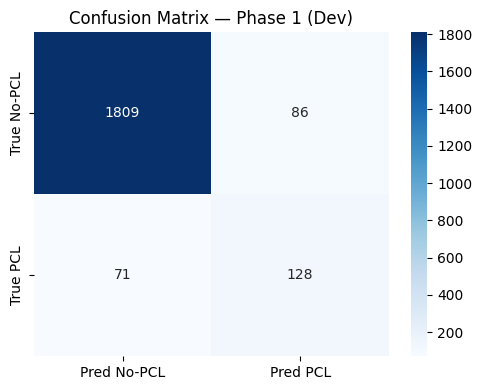

In [14]:
# ============================================================
# Phase 1 evaluation (best checkpoint)
# ============================================================
p1_eval = p1_trainer.evaluate()
print('Phase 1 dev metrics (best checkpoint):')
for k, v in p1_eval.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

p1_pred_out = p1_trainer.predict(p1_dev_ds)
y_true = p1_pred_out.label_ids
y_pred = np.argmax(p1_pred_out.predictions, axis=-1)

print('\n' + classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No-PCL', 'Pred PCL'],
            yticklabels=['True No-PCL', 'True PCL'])
plt.title('Confusion Matrix — Phase 1 (Dev)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, RUN_NAME_P1, 'confusion_matrix.png'), dpi=150)
plt.show()

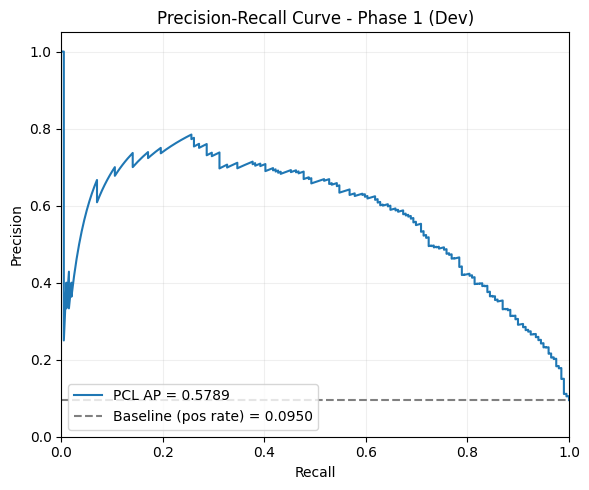

In [15]:
# ============================================================
# Precision-Recall curve (Phase 1 dev)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

logits = p1_pred_out.predictions
logits = logits - np.max(logits, axis=1, keepdims=True)  # stable softmax
exp_logits = np.exp(logits)
pcl_probs = exp_logits[:, 1] / np.sum(exp_logits, axis=1)

precision, recall, _ = precision_recall_curve(y_true, pcl_probs)
ap = average_precision_score(y_true, pcl_probs)
baseline = float(np.mean(y_true == 1))

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PCL AP = {ap:.4f}')
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--',
           label=f'Baseline (pos rate) = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Phase 1 (Dev)')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, RUN_NAME_P1, 'precision_recall_curve.png'), dpi=150)
plt.show()

In [16]:
error_df = dev_base_df.copy()
error_df['y_true'] = y_true
error_df['y_pred'] = y_pred
error_df['correct'] = (error_df['y_true'] == error_df['y_pred'])

# The four error categories
fn_df = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]  # False Negatives — missed PCL
fp_df = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]  # False Positives — wrongly flagged

In [17]:

with pd.option_context(
    'display.max_colwidth', None,
    'display.max_rows', 10
):
    print("=== FALSE NEGATIVES (PCL the model missed) ===")
    display(fn_df[['text', 'keyword', 'country']].head(10))
    
    print("\n=== FALSE POSITIVES (Not PCL but model flagged) ===")
    display(fp_df[['text', 'keyword', 'country']].head(10))

=== FALSE NEGATIVES (PCL the model missed) ===


,text,keyword,country
0,We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ; someone knowledgeable about resources they can access ; someone who can help them plan for their needs and the needs of their child by developing either a parenting plan or an adoption plan .,hopeless,us
2,"Many refugees do n't want to be resettled anywhere , let alone in the US .",refugee,ng
4,"""In a 90-degree view of his constituency , one can see a high rise and a flyover while underneath it , homeless people sleep on pavements . """" As you can see , my constituency is not confined to one socio-economic group , """" he said , adding that apart from water , another major concern for him is to improve the standard of public schools in the area .""",homeless,pk
5,"He depicts demonstrations by refugees at the border post , their catastrophic living conditions and the desperate attempt of several hundred to cross a river a few kilometres from the camp to get into Macedonia on 14 March 2016 .",refugee,nz
8,t is remiss not to mention here that not all scavenging children come from poor families . Children hailing from affluent families use dumpsites as playgrounds .,poor-families,tz
10,"Sheepherding in America has always been an immigrant 's job , too dirty , too cold and too lonely for anyone with options .",immigrant,us
12,"KARACHI - On the eve of International Women 's Day , Pakistan People 's Party Chairman Bilawal Bhutto Zardari has announced that his party 's Women Wing will organise Karwan-e-Benazir rallies in all the provincial capitals and in Azad Jammu &amp; Kashmir , Gilgit-Baltistan and Fata to celebrate the day and PPP 's achievements for empowerment of women in the country .",women,pk
15,Real poverty of Britain : Shocking images of UK in the Sixties where poor really meant poor <h> THESE hard-hitting photographs offer a glimpse into the harrowing day-to-day for poor families living in Britain during the Sixties .,poor-families,gb
18,"The World Health Organization did not give a reason for the increase in deaths , but a provincial health official in Sindh said that the disease hit areas where poor families did not vaccinate their children .",poor-families,us
19,"A top health official said today that the government could consider subsidies to help poor families pay for healthy food -- or imposing taxes on unhealthy products -- if other efforts fail to encourage better eating habits among Hong Kong residents . Dr Regina Ching from the Health Department said such moves could be explored as a way to cut levels of chronic illnesses in the city , such ...",poor-families,hk



=== FALSE POSITIVES (Not PCL but model flagged) ===


,text,keyword,country
281,The Jali family in Brown 's Farm was elated as the City of Cape Town donated wheelchairs to their disabled members .,disabled,za
286,"So , let the NPP government appointees look down upon the hardworking and selfless men and women at their own peril .",women,gh
288,""""""" So we do need to heal ourselves as an Aboriginal Torres Strait islander community , but also as a nation . """" <h> A life of hope , not hopelessness""",hopeless,au
306,""""""" The government needs to come forward , and it needs to give resources to legal aid , so that those women and those families have their basic human rights and safety met , around representation and justice , the ability to navigate that Goliath of an office with a great deal of power , and to ensure they have the education and the advocacy that they need . """" <h> Child and Youth Advocate responds""",women,ca
318,"Campaigners say over the years thousands of women , especially those from poor families , have been discarded by their husbands in this manner . Many have been rendered destitute , with nowhere to go , or have been forced to return to their parental homes or fend for themselves .",poor-families,gb
377,""""""" The fact is that ruthless smugglers are preying on desperate migrants and refugees with no regard at all for human dignity , """" said Michele Sison , the US Deputy Ambassador to the UN .""",refugee,jm
407,"Dacawi practically pioneered the concept of civic or community journalism in the city by writing on the plight of indigent patients , other people in need and worthwhile causes that moved people to respond .",in-need,ph
421,""""""" Your personal leadership has been critical to addressing the plight of the Rohingya who fled to safety in your country . I thank you for all you have done to assist these men , women and children in need , """" he wrote in the message .""",in-need,bd
449,"""E-mail Address : * <h> A clinic called """" Hope """" helps a Syrian refugee boy cope with diabetes""",refugee,ke
480,"Allman Town resident Sonya Wilson ( second left ) , and one of her daughters ( fourth left ) hand out boxed lunches to a group of homeless people on King Street , downtown Kingston , on Thursday .",homeless,jm


In [18]:
keyword_analysis = error_df.groupby('keyword').apply(
    lambda g: pd.Series({
        'total': len(g),
        'fn': ((g.y_true==1) & (g.y_pred==0)).sum(),
        'fp': ((g.y_true==0) & (g.y_pred==1)).sum(),
        'f1': f1_score(g.y_true, g.y_pred, zero_division=0)
    })
).round(3)
print(keyword_analysis.sort_values('f1'))

               total    fn    fp     f1
keyword                                
refugee        188.0   7.0  10.0  0.414
women          233.0   8.0   3.0  0.522
hopeless       217.0  10.0  18.0  0.533
disabled       194.0   7.0   5.0  0.538
homeless       212.0  10.0  14.0  0.613
immigrant      218.0   3.0   2.0  0.615
poor-families  190.0  15.0  13.0  0.622
migrant        207.0   1.0   3.0  0.667
vulnerable     209.0   6.0   5.0  0.718
in-need        226.0   4.0  13.0  0.773


/tmp/ipykernel_23/4250540617.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  keyword_analysis = error_df.groupby('keyword').apply(


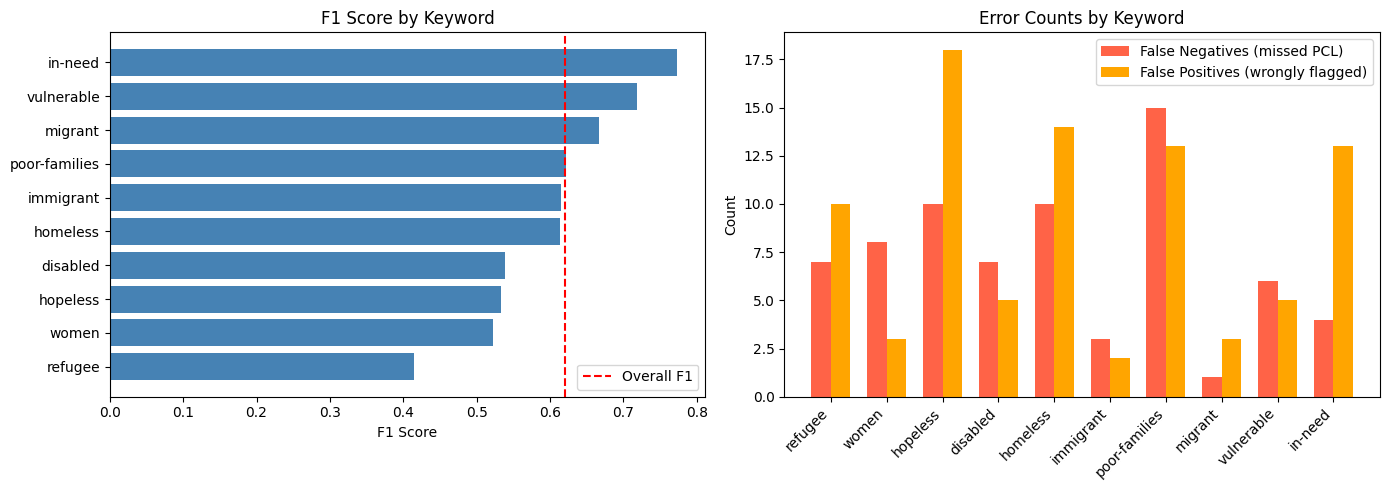

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by keyword
keyword_analysis_sorted = keyword_analysis.sort_values('f1')
axes[0].barh(keyword_analysis_sorted.index, keyword_analysis_sorted['f1'], color='steelblue')
axes[0].axvline(x=f1_score(y_true, y_pred, zero_division=0), color='red', linestyle='--', label='Overall F1')
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score by Keyword')
axes[0].legend()

# FN and FP counts by keyword
x = range(len(keyword_analysis_sorted))
width = 0.35
axes[1].bar([i - width/2 for i in x], keyword_analysis_sorted['fn'], width, label='False Negatives (missed PCL)', color='tomato')
axes[1].bar([i + width/2 for i in x], keyword_analysis_sorted['fp'], width, label='False Positives (wrongly flagged)', color='orange')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(keyword_analysis_sorted.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Counts by Keyword')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, RUN_NAME_P1, "error_breakdown_by_keyword.png"), dpi=300)
plt.show()

# Generate dev and test results for Global Evaluation

In [20]:
# ============================================================
# Generate dev.txt  (official dev split order)
# ============================================================
# dev_base_df was ordered to match dev_ids_df, so p1_dev_ds rows align directly.
dev_preds = y_pred.tolist()

assert set(dev_preds).issubset({0, 1}), 'Unexpected values in dev predictions'
assert len(dev_preds) == len(dev_base_df), (
    f'Dev count mismatch: {len(dev_preds)} vs {len(dev_base_df)}'
)

with open(DEV_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in dev_preds) + '\n')

print(f'Written {len(dev_preds):,} predictions -> {DEV_TXT_PATH}')

Written 2,094 predictions -> dev.txt


---
## Phase 2 — Full retrain on all labelled data
Train + aug_train + dev + aug_dev combined; no held-out validation set.
A **fresh** `roberta-base` is used (same hyperparameters as Phase 1).

In [21]:
# ============================================================
# Phase 2 training set: train_base + aug_train + dev_base + aug_dev
# ============================================================
p2_train_df = pd.concat(
    [train_base_df, aug_train_df, dev_base_df, aug_dev_df],
    ignore_index=True,
).sample(frac=1, random_state=SEED).reset_index(drop=True)

p2_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=p2_train_df['label'].values)

print(f'Phase 2 train: {len(p2_train_df):,} | PCL={int((p2_train_df.label==1).sum()):,} | No-PCL={int((p2_train_df.label==0).sum()):,}')
print(f'Class weights -> No-PCL: {p2_cw[0]:.4f},  PCL: {p2_cw[1]:.4f}')

p2_train_ds = build_dataset(p2_train_df)
print(p2_train_ds)

Phase 2 train: 18,015 | PCL=8,539 | No-PCL=9,476
Class weights -> No-PCL: 0.9506,  PCL: 1.0549


Map:   0%|          | 0/18015 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 18015
})


Only used 3 epoch here instead of 5 because from the training above it seems that the model starts overfitting around epochs 2 and 3. But for the above it's fine because I am saving the best model anyways, not the final model.

In [22]:
# ============================================================
# Phase 2 model + trainer  (fresh roberta-base, no eval set)
# ============================================================
p2_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p2_args = TrainingArguments(
    output_dir=RUN_NAME_P2,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-5,
    eval_strategy='no',        # no validation set in Phase 2
    save_strategy='no',        # save only the final model below
    report_to='none',
    seed=SEED,
)

p2_trainer = Trainer(
    model=p2_model,
    args=p2_args,
    train_dataset=p2_train_ds,
    processing_class=tokenizer,
    data_collator=data_collator
)

print('Phase 2 trainer configured.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 2 trainer configured.


In [23]:
p2_train_result = p2_trainer.train()
print(p2_train_result)

# Save final Phase 2 model
p2_final_dir = os.path.join(RUN_NAME_P2, 'final')
p2_trainer.save_model(p2_final_dir)
tokenizer.save_pretrained(p2_final_dir)
print(f'Phase 2 model saved to: {p2_final_dir}')

Step,Training Loss
500,0.569441
1000,0.526684
1500,0.498667
2000,0.433852
2500,0.416189
3000,0.339906
3500,0.368227
4000,0.351975
4500,0.351063
5000,0.190536


TrainOutput(global_step=13512, training_loss=0.20638031358413544, metrics={'train_runtime': 830.7454, 'train_samples_per_second': 65.056, 'train_steps_per_second': 16.265, 'total_flos': 2709776648042400.0, 'train_loss': 0.20638031358413544, 'epoch': 3.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Phase 2 model saved to: checkpoints/phase2/final


Error reported above is average training loss over all 3 epochs.

In [24]:
# ============================================================
# Generate test.txt  (3832 predictions in test file order)
# ============================================================
test_df = load_test_tsv(TEST_PATH)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df['model_text'] = make_model_text(test_df)

test_ds       = build_dataset(test_df, has_labels=False)
test_pred_out = p2_trainer.predict(test_ds)
test_preds    = np.argmax(test_pred_out.predictions, axis=-1).tolist()

assert set(test_preds).issubset({0, 1}), 'Unexpected values in test predictions'
assert len(test_preds) == len(test_df), (
    f'Test count mismatch: {len(test_preds)} vs {len(test_df)}'
)

with open(TEST_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in test_preds) + '\n')

print(f'Written {len(test_preds):,} predictions -> {TEST_TXT_PATH}  (expected 3832)')

Map:   0%|          | 0/3832 [00:00<?, ? examples/s]

Written 3,832 predictions -> test.txt  (expected 3832)


In [25]:
# ============================================================
# Sanity checks on output files
# ============================================================
for path in [DEV_TXT_PATH, TEST_TXT_PATH]:
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip()]
    print(f'{path:12s}: lines={len(lines):,}, unique_labels={sorted(set(lines))}')

dev.txt     : lines=2,094, unique_labels=['0', '1']
test.txt    : lines=3,832, unique_labels=['0', '1']
